# Data Analysis (cavity_claw_RouteMeander_eigenmode)
## Qiskit Metal --> Hamiltonian Params

Ansys surrogate model

## Configuration

Disable cell scrolling.

Parameters are stored in a shared script.

In [8]:
from parameters_surrogate import *

In [9]:
# make directory for data and scaler saving
os.makedirs('scalers', exist_ok=True)
os.makedirs(f'{DATA_DIR}', exist_ok=True)
os.makedirs(f'{DATA_DIR}/npy', exist_ok=True)

## Library

In [10]:
import json
import numpy as np
import pandas as pd
from pandas import json_normalize
import joblib
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

## Datasets

### Load
From https://huggingface.co/datasets/SQuADDS/SQuADDS_DB/tree/main

In [11]:
df = pd.read_json("cavity_claw-RouteMeander-eigenmode.json")

#dropping datasets where design.resonator_type is "half"
mask = df["design"].apply(
    lambda d: str(d.get("resonator_type", "")).strip().lower() != "half"
)

df = df.loc[mask].reset_index(drop=True)

print("Remaining rows:", len(df))
print("Removed rows:", (~mask).sum())
print("Remaining resonator types:\n",
      df["design"].apply(lambda d: d.get("resonator_type", None)).value_counts(dropna=False))

Remaining rows: 810
Removed rows: 406
Remaining resonator types:
 design
quarter    810
Name: count, dtype: int64


### Look at the data and structure

In [12]:
#look at the first value
first_entry = df.iloc[100]

# Print the headers and their corresponding values
for header, value in first_entry.items():
    print(f"{header}: {value}")

sim_options: {'setup': {'name': 'Setup', 'reuse_selected_design': True, 'reuse_setup': True, 'min_freq_ghz': 1, 'n_modes': 1, 'max_delta_f': 0.05, 'max_passes': 50, 'min_passes': 1, 'min_converged': 1, 'pct_refinement': 30, 'basis_order': 1, 'vars': {'Lj': '0nH', 'Cj': '0fF'}, 'min_converged_passes': 2}, 'simulator': 'Ansys HFSS'}
sim_results: {'cavity_frequency': 5987186143.809999, 'kappa': 22053.7288176, 'units': 'Hz'}
design: {'design_options': {'claw_opts': {'connection_pads': {'readout': {'connector_location': '90', 'connector_type': '0', 'claw_length': '440um', 'ground_spacing': '4.1um', 'claw_gap': '5.1um', 'claw_width': '15um', 'claw_cpw_width': '11.7um', 'claw_cpw_length': '0um'}}, 'orientation': '-90', 'pos_x': '-1500um', 'cross_length': '0um', 'cross_width': '0um', 'cross_gap': '0um'}, 'cpw_opts': {'fillet': '49.9um', 'total_length': '3900um', 'trace_width': '11.7um', 'trace_gap': '5.1um', 'lead': {'start_straight': '50um'}, 'pin_inputs': {'start_pin': {'component': 'cplr', 

In [13]:
#Look at the headers relevant for us, to start lets only look at the sim_results (our x data) and design (our y data)
sim_results_column = df['sim_results']
print(sim_results_column, '\n\n')

design_column = df['design']
print(design_column)

0      {'cavity_frequency': 5353549772.64, 'kappa': 1...
1      {'cavity_frequency': 8399240836.29, 'kappa': 2...
2      {'cavity_frequency': 8694844797.89, 'kappa': 2...
3      {'cavity_frequency': 6616574393.559999, 'kappa...
4      {'cavity_frequency': 7986835171.7, 'kappa': 20...
                             ...                        
805    {'cavity_frequency': 7489688801.09, 'kappa': 4...
806    {'cavity_frequency': 7452442461.75, 'kappa': 3...
807    {'cavity_frequency': 7415826341.76, 'kappa': 4...
808    {'cavity_frequency': 7378752058.07, 'kappa': 4...
809    {'cavity_frequency': 7342036181.17, 'kappa': 5...
Name: sim_results, Length: 810, dtype: object 


0      {'design_options': {'claw_opts': {'connection_...
1      {'design_options': {'claw_opts': {'connection_...
2      {'design_options': {'claw_opts': {'connection_...
3      {'design_options': {'claw_opts': {'connection_...
4      {'design_options': {'claw_opts': {'connection_...
                             ...       

In [14]:
#take a look at everything in the design dataset
# Flatten the design column
design_flat = json_normalize(df['design'])

# List all column headers
design_column_vals = design_flat.columns.tolist()
print(design_column_vals)
print('length: ',len(design_column_vals))

['coupler_type', 'resonator_type', 'design_tool', 'design_options.claw_opts.connection_pads.readout.connector_location', 'design_options.claw_opts.connection_pads.readout.connector_type', 'design_options.claw_opts.connection_pads.readout.claw_length', 'design_options.claw_opts.connection_pads.readout.ground_spacing', 'design_options.claw_opts.connection_pads.readout.claw_gap', 'design_options.claw_opts.connection_pads.readout.claw_width', 'design_options.claw_opts.connection_pads.readout.claw_cpw_width', 'design_options.claw_opts.connection_pads.readout.claw_cpw_length', 'design_options.claw_opts.orientation', 'design_options.claw_opts.pos_x', 'design_options.claw_opts.cross_length', 'design_options.claw_opts.cross_width', 'design_options.claw_opts.cross_gap', 'design_options.cpw_opts.fillet', 'design_options.cpw_opts.total_length', 'design_options.cpw_opts.trace_width', 'design_options.cpw_opts.trace_gap', 'design_options.cpw_opts.lead.start_straight', 'design_options.cpw_opts.pin_inp

### Reformat

In [15]:
#flatten what will be our Hamiltonian param data 
X_cap = json_normalize(df['sim_results'])
# Dropping the 'units' column for now because they are all in Hz and this info isnt useful
X_cap = X_cap.drop(columns=['units'])
print(X_cap)

     cavity_frequency          kappa
0        5.353550e+09  161106.598429
1        8.399241e+09  268412.116632
2        8.694845e+09  255873.654612
3        6.616574e+09   30459.761161
4        7.986835e+09  208304.221064
..                ...            ...
805      7.489689e+09   46004.713078
806      7.452442e+09   38837.211205
807      7.415826e+09   46696.417529
808      7.378752e+09   41526.048615
809      7.342036e+09   58463.648381

[810 rows x 2 columns]


In [16]:
# Flatten the Qiskit Metal design parameters
y_design = json_normalize(df['design'])

#get rid of this column because there are two spellings in the dataset that will confuse the NN. We always just use Qiskit, so for now we dont need this
columns_to_drop = ['design_options.claw_opts.connection_pads.readout.connector_location',
 'design_options.claw_opts.connection_pads.readout.connector_type',
 'design_options.claw_opts.connection_pads.readout.claw_gap',
 'design_options.claw_opts.connection_pads.readout.claw_width',
 'design_options.claw_opts.connection_pads.readout.claw_cpw_width',
 'design_options.claw_opts.connection_pads.readout.claw_cpw_length',
 'design_options.claw_opts.orientation',
 'design_options.claw_opts.pos_x',
 'design_options.claw_opts.cross_length',
 'design_options.claw_opts.cross_width',
 'design_options.claw_opts.cross_gap',
 'design_options.cpw_opts.fillet',
 'design_options.cpw_opts.trace_width',
 'design_options.cpw_opts.trace_gap',
 'design_options.cpw_opts.pin_inputs.start_pin.component',
 'design_options.cpw_opts.pin_inputs.start_pin.pin',
 'design_options.cpw_opts.pin_inputs.end_pin.component',
 'design_options.cpw_opts.pin_inputs.end_pin.pin',
 'design_options.cpw_opts.meander.spacing',
 'design_options.cplr_opts.prime_width',
 'design_options.cplr_opts.prime_gap',
 'design_options.cplr_opts.second_width',
 'design_options.cplr_opts.second_gap',
 'design_options.cplr_opts.coupling_space',
 'design_options.cplr_opts.open_termination',
 'design_options.cplr_opts.down_length',
 'design_options.cplr_opts.orientation',
 'coupler_type',
 'resonator_type',
 'design_tool',
 'design_options.cpw_opts.lead.end_straight',
 'design_options.cpw_opts.lead.start_straight',
 'design_options.cpw_opts.lead.start_jogged_extension.0',
 ]

#output of processing later on when I dont drop design_tool column:
'''
One-hot encoding for 'design_tool':
      design_tool_Qiskit Metal  design_tool_qiskit-metal
 0                          0.0                       1.0 
'''

y_design = y_design.drop(columns=columns_to_drop)

print(f'y_design shape: {y_design.shape}')
print(y_design)

y_design shape: (810, 5)
    design_options.claw_opts.connection_pads.readout.claw_length  \
0                                                220um             
1                                                270um             
2                                                210um             
3                                                210um             
4                                                360um             
..                                                 ...             
805                                              380um             
806                                              390um             
807                                              400um             
808                                              410um             
809                                              420um             

    design_options.claw_opts.connection_pads.readout.ground_spacing  \
0                                                4.1um                
1               

### Validate and View Data

In [17]:
display(X_cap)

,cavity_frequency,kappa
0,5.353550e+09,161106.598429
1,8.399241e+09,268412.116632
2,8.694845e+09,255873.654612
3,6.616574e+09,30459.761161
4,7.986835e+09,208304.221064
...,...,...
805,7.489689e+09,46004.713078
806,7.452442e+09,38837.211205
807,7.415826e+09,46696.417529
808,7.378752e+09,41526.048615


In [18]:
display(y_design)

,design_options.claw_opts.connection_pads.readout.claw_length,design_options.claw_opts.connection_pads.readout.ground_spacing,design_options.cpw_opts.total_length,design_options.cpw_opts.meander.asymmetry,design_options.cplr_opts.coupling_length
0,220um,4.1um,4700um,-175.0um,350um
1,270um,4.1um,2700um,-100.0um,200um
2,210um,4.1um,2700um,66.66666666666667um,200um
3,210um,4.1um,3900um,-50.0um,100um
4,360um,4.1um,2700um,66.66666666666667um,200um
...,...,...,...,...,...
805,380um,10um,3000um,0.0um,100um
806,390um,10um,3000um,0.0um,100um
807,400um,10um,3000um,0.0um,100um
808,410um,10um,3000um,0.0um,100um


## Transform Y to Numerical Values

We need all columns to be numeric floats for the MLP. This means stripping units like 'um' and 'nH',
converting to SI, and filling NaNs.

In [19]:
#look at the format all of the y values are in
for col in y_design.columns:
    print(f"{col}  {y_design[col].iloc[0]}")
print(y_design.shape)

design_options.claw_opts.connection_pads.readout.claw_length  220um
design_options.claw_opts.connection_pads.readout.ground_spacing  4.1um
design_options.cpw_opts.total_length  4700um
design_options.cpw_opts.meander.asymmetry  -175.0um
design_options.cplr_opts.coupling_length  350um
(810, 5)


In [20]:
y_numerical = y_design.copy()

In [21]:
# Strip units (um, nH) and convert to SI
y_numerical_clean = y_numerical.copy()

# Extract numerical values and convert units (assuming 'um' for some columns)
um_cols = [col for col in y_numerical_clean.columns if y_numerical_clean[col].astype(str).str.contains('um').any()]

for col in um_cols:
    y_numerical_clean[col] = pd.to_numeric(y_numerical_clean[col].astype(str).str.replace('um', '', regex=False), errors='coerce') * 1e-6
    y_numerical_clean[col] = y_numerical_clean[col].round(15)

nH_cols = [col for col in y_numerical_clean.columns if y_numerical_clean[col].astype(str).str.contains('nH').any()]
for col in nH_cols:
    y_numerical_clean[col] = pd.to_numeric(y_numerical_clean[col].astype(str).str.replace('nH', '', regex=False), errors='coerce') * 1e-9
    y_numerical_clean[col] = y_numerical_clean[col].round(15)

for col in y_numerical_clean.columns:
    try:
        print(f"{col}-----------Numerical: {y_numerical_clean[col].iloc[0]}-----------Original: {y_design[col].iloc[0]}")
    except KeyError:
        print(f'{col} -- changed')

design_options.claw_opts.connection_pads.readout.claw_length-----------Numerical: 0.00022-----------Original: 220um
design_options.claw_opts.connection_pads.readout.ground_spacing-----------Numerical: 4.1e-06-----------Original: 4.1um
design_options.cpw_opts.total_length-----------Numerical: 0.0047-----------Original: 4700um
design_options.cpw_opts.meander.asymmetry-----------Numerical: -0.000175-----------Original: -175.0um
design_options.cplr_opts.coupling_length-----------Numerical: 0.00035-----------Original: 350um


In [22]:
# Print how many columns have NaN in them
for col in y_design.columns:
    total = len(y_design[col])
    n_nan = y_design[col].isna().sum()
    if 0 < n_nan < total:
        pct_nan = n_nan / total * 100
        zero_mask = y_design[col].astype(str).str.contains('0.0', na=False)
        n_zero = zero_mask.sum()
        pct_zero = n_zero / total * 100
        print(f"{col}:")
        print(f"  NaN values:  {n_nan}/{total}  ({pct_nan:.2f}%)")
        print(f"  '0.0' vals:  {n_zero}/{total}  ({pct_zero:.2f}%)")
        print()

In [24]:
# Fill NaN with 1 
y_numerical_clean.fillna(float(1), inplace=True)

print('Now all of these should be numerical:')
for col in y_numerical_clean.columns:
    print(f"{col}-----------{y_numerical_clean[col].iloc[0]}")

Now all of these should be numerical:
design_options.claw_opts.connection_pads.readout.claw_length-----------0.00022
design_options.claw_opts.connection_pads.readout.ground_spacing-----------4.1e-06
design_options.cpw_opts.total_length-----------0.0047
design_options.cpw_opts.meander.asymmetry------------0.000175
design_options.cplr_opts.coupling_length-----------0.00035


In [25]:
y_final = y_numerical_clean.copy()
print('Final y shape:', y_final.shape)
display(y_final)

Final y shape: (810, 5)


,design_options.claw_opts.connection_pads.readout.claw_length,design_options.claw_opts.connection_pads.readout.ground_spacing,design_options.cpw_opts.total_length,design_options.cpw_opts.meander.asymmetry,design_options.cplr_opts.coupling_length
0,0.00022,0.000004,0.0047,-0.000175,0.00035
1,0.00027,0.000004,0.0027,-0.000100,0.00020
2,0.00021,0.000004,0.0027,0.000067,0.00020
3,0.00021,0.000004,0.0039,-0.000050,0.00010
4,0.00036,0.000004,0.0027,0.000067,0.00020
...,...,...,...,...,...
805,0.00038,0.000010,0.0030,0.000000,0.00010
806,0.00039,0.000010,0.0030,0.000000,0.00010
807,0.00040,0.000010,0.0030,0.000000,0.00010
808,0.00041,0.000010,0.0030,0.000000,0.00010


### Save the header names of the y data

In [26]:
filename = 'y_characteristics_linear_encoding.csv'
headers = list(y_final.columns)
with open(filename, 'w') as f:
    f.write(','.join(headers))
print(f'Saved {filename} with {len(headers)} columns')

Saved y_characteristics_linear_encoding.csv with 5 columns


## Visualize

### X Data (Hamiltonian Param values)

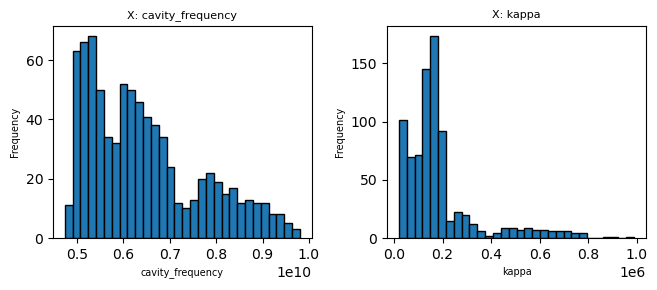

In [27]:
num_cols = len(X_cap.columns)
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i, col in enumerate(X_cap.columns):
    axes[i].hist(X_cap[col], bins=30, edgecolor='black')
    axes[i].set_title(f'X: {col}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/model2_x_cap_distribution.pdf')
plt.show()

### Y Data (Qiskit Metal params)

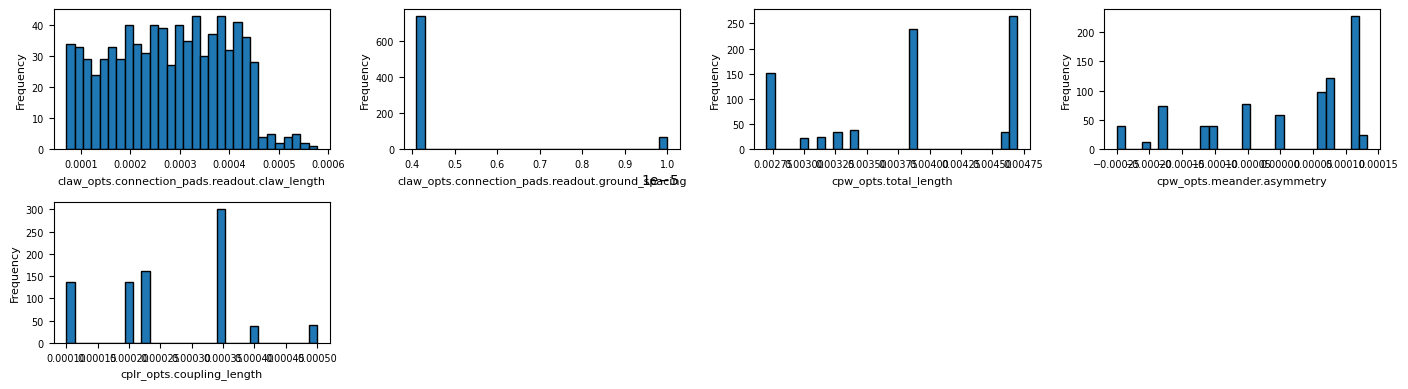

In [28]:
num_cols = len(y_final.columns)
num_rows = ((num_cols + 2) // 4) + 1

plt.figure(figsize=(14, 2 * num_rows))

for n, col in enumerate(y_final.columns):
    try:
        plt.subplot(num_rows, 4, n + 1)
        plt.hist(y_final[col], bins=30, edgecolor='black')
        plt.xlabel(col.split('design_options.')[-1], fontsize=8)
        plt.ylabel('Frequency', fontsize=8)
        plt.tick_params(axis='both', which='major', labelsize=7)
    except TypeError:
        print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")

plt.tight_layout()
plt.savefig('plots/model2_unscaled_y_design_distribution.png')
plt.show()

In [29]:
plt.close()

## Split

Dataset split is 70%-15%-15% training-validation-test. We use a constant state (seed) for reproducible splits.

In [30]:
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X_cap, y_final, test_size=0.3, random_state=42, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=0.5, random_state=42, shuffle=True
)

In [31]:
total = y_train.shape[0] + y_test.shape[0] + y_val.shape[0]
print('---------------------------------------')
print('Train set shape: {}, {:.2f}%'.format(y_train.shape, (y_train.shape[0]*100.)/total))
print('Validation set shape: {}, {:.2f}%'.format(y_val.shape, (y_val.shape[0]*100.)/total))
print('Test set shape: {}, {:.2f}%'.format(y_test.shape, (y_test.shape[0]*100.)/total))
print('---------------------------------------')

---------------------------------------
Train set shape: (567, 5), 70.00%
Validation set shape: (121, 5), 14.94%
Test set shape: (122, 5), 15.06%
---------------------------------------


## Augment

### Scale X (Hamiltonian Param values)

Scale Hamiltonian Param values to be between 0 and 1

In [32]:
def scale_splits_per_column(train_df, val_df, test_df, scaler_name_prefix):
    train_s = train_df.copy()
    val_s   = val_df.copy()
    test_s  = test_df.copy()

    scalers = {}
    for col in train_df.columns:
        sc = MinMaxScaler()
        sc.fit(train_df[[col]])

        train_s[col] = sc.transform(train_df[[col]])
        val_s[col]   = sc.transform(val_df[[col]])
        test_s[col]  = sc.transform(test_df[[col]])

        scalers[col] = sc
        joblib.dump(sc, f'scalers/{scaler_name_prefix}_{col}.save')

    return train_s, val_s, test_s, scalers

X_train_scaled, X_val_scaled, X_test_scaled, x_scalers = scale_splits_per_column(
    X_train, X_val, X_test,
    scaler_name_prefix='scaler_X_linear'
)

In [33]:
# look at the scaled stuff to check
display(X_train_scaled.head())
display(X_val_scaled.head())
display(X_test_scaled.head())

,cavity_frequency,kappa
777,0.503508,0.132124
436,0.280795,0.100609
132,0.685880,0.195902
506,0.155873,0.174880
266,0.255033,0.000000


,cavity_frequency,kappa
351,0.888016,0.058505
758,0.012355,0.137984
605,0.065170,0.124569
352,0.876498,0.051322
730,0.115506,0.197416


,cavity_frequency,kappa
39,0.291146,0.004451
198,0.721199,0.150955
331,0.587419,0.493966
529,0.059281,0.127624
377,1.013227,0.066495


### Scale Y (Qiskit Metal params)

In [34]:
y_train_scaled, y_val_scaled, y_test_scaled, y_scalers = scale_splits_per_column(
    y_train, y_val, y_test,
    scaler_name_prefix='scaler_y_linear'
)

In [35]:
# look at the scaled stuff to check
display(y_train_scaled.head())
display(y_val_scaled.head())
display(y_test_scaled.head())

,design_options.claw_opts.connection_pads.readout.claw_length,design_options.claw_opts.connection_pads.readout.ground_spacing,design_options.cpw_opts.total_length,design_options.cpw_opts.meander.asymmetry,design_options.cplr_opts.coupling_length
777,0.492611,1.0,0.225,0.826087,0.250
436,0.482759,0.0,0.600,0.852174,0.325
132,0.492611,0.0,0.000,0.391304,0.250
506,0.142857,0.0,1.000,0.956522,0.625
266,0.709360,0.0,0.600,0.521739,0.000


,design_options.claw_opts.connection_pads.readout.claw_length,design_options.claw_opts.connection_pads.readout.ground_spacing,design_options.cpw_opts.total_length,design_options.cpw_opts.meander.asymmetry,design_options.cplr_opts.coupling_length
351,0.197044,0.0,0.0,0.652174,0.000
758,0.866995,0.0,1.0,1.000000,0.750
605,0.600985,0.0,1.0,0.956522,0.625
352,0.216749,0.0,0.0,0.652174,0.000
730,0.275862,1.0,1.0,0.130435,0.750


,design_options.claw_opts.connection_pads.readout.claw_length,design_options.claw_opts.connection_pads.readout.ground_spacing,design_options.cpw_opts.total_length,design_options.cpw_opts.meander.asymmetry,design_options.cplr_opts.coupling_length
39,0.571429,0.0,0.6,0.521739,0.000
198,0.413793,0.0,0.0,0.391304,0.250
331,0.571429,0.0,0.0,0.956522,0.625
529,0.635468,0.0,1.0,0.956522,0.625
377,0.000000,0.0,0.0,0.652174,0.000


### Plot Scaled Data

### X

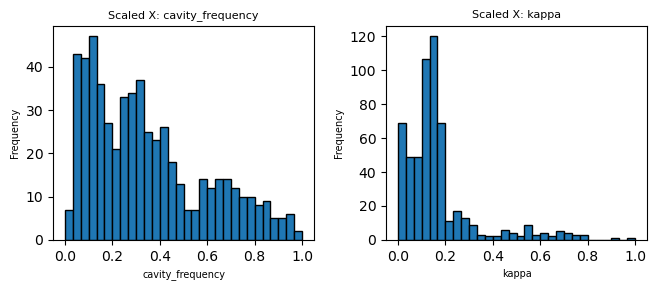

In [36]:
num_cols = len(X_cap.columns)
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i, col in enumerate(X_train_scaled.columns):
    axes[i].hist(X_train_scaled[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Scaled X: {col}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/model2_scaled_x_cap_distribution.pdf')
plt.show()

### Y

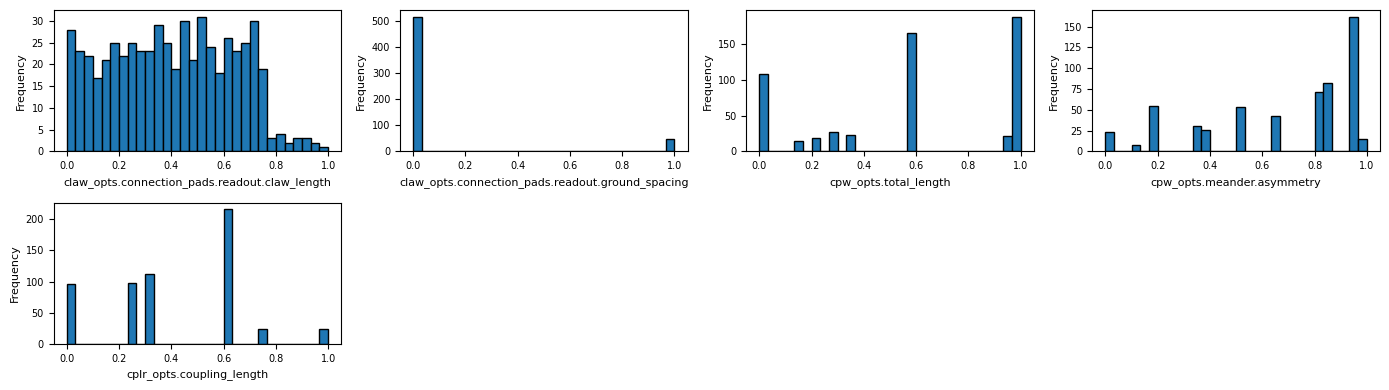

In [37]:
num_cols = len(y_train_scaled.columns)
num_rows = ((num_cols + 2) // 4) + 1

plt.figure(figsize=(14, 2 * num_rows))

for n, col in enumerate(y_train_scaled.columns):
    try:
        plt.subplot(num_rows, 4, n + 1)
        plt.hist(y_train_scaled[col], bins=30, edgecolor='black')
        plt.xlabel(col.split('design_options.')[-1], fontsize=8)
        plt.ylabel('Frequency', fontsize=8)
        plt.tick_params(axis='both', which='major', labelsize=7)
    except TypeError:
        print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")

plt.tight_layout()
plt.savefig('plots/model2_scaled_y_design_distribution.png')
plt.show()

In [38]:
plt.close()

## Unscaling

To make sure we can recreate original values with saved scaler (compare with above cells)

### Unscale X

In [39]:
X_check = X_train_scaled
prefix = 'scaler_X_linear'

X_orig = X_check.copy()
for col in X_check.columns:
    sc = joblib.load(f'scalers/{prefix}_{col}.save')
    X_orig[col] = sc.inverse_transform(X_check[[col]])

display(X_orig.head())

,cavity_frequency,kappa
777,7.254503e+09,148291.727434
436,6.140140e+09,117772.407240
132,8.167019e+09,210054.856626
506,5.515081e+09,189696.387697
266,6.011236e+09,20342.662102


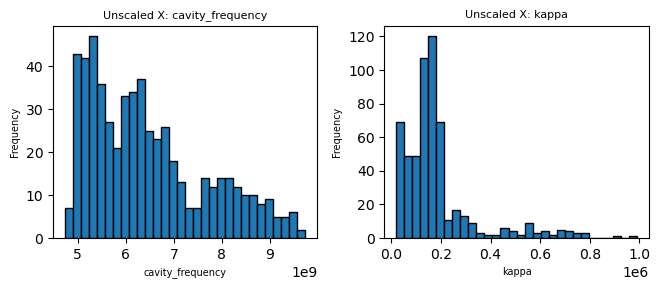

In [40]:
num_cols = len(X_cap.columns)
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i, col in enumerate(X_orig.columns):
    axes[i].hist(X_orig[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Unscaled X: {col}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/model2_unscaled_x_check.pdf')
plt.show()

### Unscale Y

In [41]:
prefix = 'scaler_y_linear'
y_orig = y_train_scaled.copy()

for col in y_train_scaled.columns:
    sc = joblib.load(f'scalers/{prefix}_{col}.save')
    y_orig[col] = sc.inverse_transform(y_train_scaled[[col]])

display(y_orig.head())

,design_options.claw_opts.connection_pads.readout.claw_length,design_options.claw_opts.connection_pads.readout.ground_spacing,design_options.cpw_opts.total_length,design_options.cpw_opts.meander.asymmetry,design_options.cplr_opts.coupling_length
777,0.000320,0.000010,0.00315,0.000067,0.00020
436,0.000315,0.000004,0.00390,0.000077,0.00023
132,0.000320,0.000004,0.00270,-0.000100,0.00020
506,0.000142,0.000004,0.00470,0.000117,0.00035
266,0.000430,0.000004,0.00390,-0.000050,0.00010


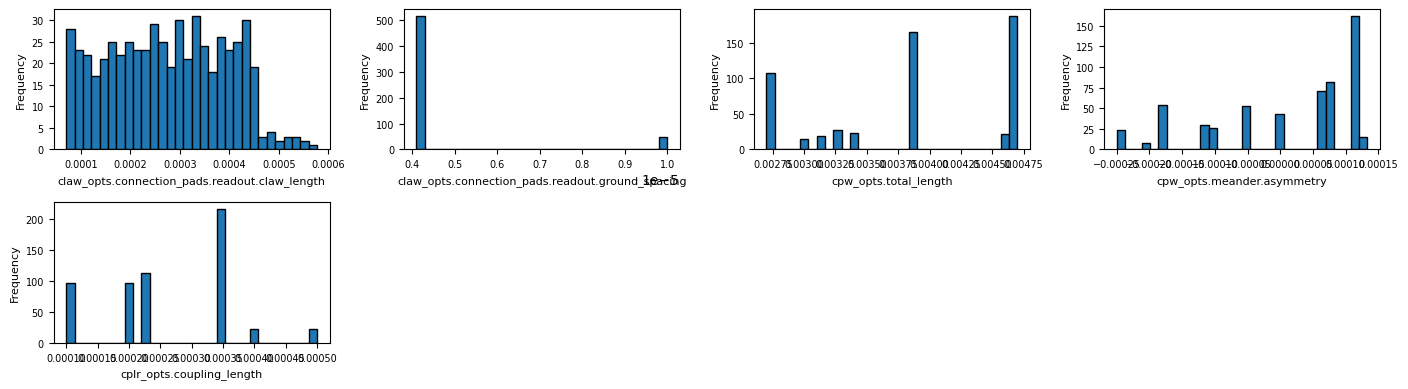

In [42]:
num_cols = len(y_orig.columns)
num_rows = ((num_cols + 2) // 4) + 1

plt.figure(figsize=(14, 2 * num_rows))

for j, col in enumerate(y_orig.columns):
    plt.subplot(num_rows, 4, j + 1)
    plt.hist(y_orig[col], bins=30, edgecolor='black')
    plt.xlabel(col.split('design_options.')[-1], fontsize=8)
    plt.ylabel('Frequency', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=7)


plt.tight_layout()
plt.savefig('plots/model2_unscaled_y_check.png')
plt.show()

## Save

In [43]:
!rm -f $DATA_DIR/npy/*npy

In [44]:
# Unscaled
np.save(f'{DATA_DIR}/npy/x_train_linear_encoding.npy', X_train)
np.save(f'{DATA_DIR}/npy/x_val_linear_encoding.npy', X_val)
np.save(f'{DATA_DIR}/npy/x_test_linear_encoding.npy', X_test)

np.save(f'{DATA_DIR}/npy/y_train_linear_encoding.npy', y_train)
np.save(f'{DATA_DIR}/npy/y_val_linear_encoding.npy', y_val)
np.save(f'{DATA_DIR}/npy/y_test_linear_encoding.npy', y_test)

print(f'Unscaled data saved in: {DATA_DIR}/npy')

Unscaled data saved in: data/npy


In [45]:
# Scaled
np.save(f'{DATA_DIR}/npy/x_train_linear_encoding_scaled.npy', X_train_scaled)
np.save(f'{DATA_DIR}/npy/x_val_linear_encoding_scaled.npy',   X_val_scaled)
np.save(f'{DATA_DIR}/npy/x_test_linear_encoding_scaled.npy',  X_test_scaled)

np.save(f'{DATA_DIR}/npy/y_train_linear_encoding_scaled.npy', y_train_scaled)
np.save(f'{DATA_DIR}/npy/y_val_linear_encoding_scaled.npy',   y_val_scaled)
np.save(f'{DATA_DIR}/npy/y_test_linear_encoding_scaled.npy',  y_test_scaled)

print(f'Scaled data saved in: {DATA_DIR}/npy')

Scaled data saved in: data/npy


In [46]:
!ls $DATA_DIR/npy/*npy

data/npy/x_test_linear_encoding.npy
data/npy/x_test_linear_encoding_scaled.npy
data/npy/x_train_linear_encoding.npy
data/npy/x_train_linear_encoding_scaled.npy
data/npy/x_val_linear_encoding.npy
data/npy/x_val_linear_encoding_scaled.npy
data/npy/y_test_linear_encoding.npy
data/npy/y_test_linear_encoding_scaled.npy
data/npy/y_train_linear_encoding.npy
data/npy/y_train_linear_encoding_scaled.npy
data/npy/y_val_linear_encoding.npy
data/npy/y_val_linear_encoding_scaled.npy


In [47]:
# saving column names (where H params=X_names, Qiskit params=y_columns)
with open('X_names', 'w') as f:
    f.write('\n'.join(X_cap.columns))

np.save('y_columns.npy', np.array(y_train.columns))
print(f'Saved X_names ({len(X_cap.columns)} cols) and y_columns.npy ({len(y_train.columns)} cols)')

Saved X_names (2 cols) and y_columns.npy (5 cols)
